In [4]:
!pip install pandas matplotlib numpy seaborn openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

%matplotlib inline
sns.set(style="darkgrid")
plt.rcParams['figure.figsize'] = (15, 5)
plt.style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

# Set pandas display options
pd.options.display.float_format = '{:.3f}'.format

In [5]:
# Download if not already present (you may need to run wget commands)
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls
!mv -f 'default of credit card clients.xls' 'CreditCard.xls'

df = pd.read_excel('CreditCard.xls', header=1, index_col=0)
df.head(7)

--2026-06-17 05:12:31--  https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘default of credit card clients.xls’

default of credit c     [   <=>              ]   5.28M  12.9MB/s    in 0.4s    

2026-06-17 05:12:32 (12.9 MB/s) - ‘default of credit card clients.xls’ saved [5539328]



,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
6,50000,1,1,2,37,0,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
7,500000,1,1,2,29,0,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0


In [6]:
# Shape (rows, columns)
print(df.shape)   # (30000, 24)

# Column names
print(df.columns)

# Data types and missing values
df.info()

(30000, 24)
Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-nu

In [7]:
df.describe()
df["default payment next month"].value_counts(normalize=True)
df["MARRIAGE"].value_counts(normalize=True)

,proportion
MARRIAGE,
2,0.532
1,0.455
3,0.011
0,0.002


In [8]:
from numpy import unique

counts = df.nunique()
for_delete = [i for i, v in enumerate(counts) if v == 1]

if for_delete:
    print('Columns to drop (by index):', for_delete)
    df.drop(for_delete, axis=1, inplace=True)
else:
    print('No constant columns found.')

print('New shape:', df.shape)  # Still (30000, 24)
print("Nr \t UV \t %")
print("======================")
for i in range(df.shape[1]):
    num = len(unique(df.iloc[:, i]))
    percentage = float(num) / df.shape[0] * 100
    print(f'{i}\t {num}\t {percentage:.1f}')
print("======================")

No constant columns found.
New shape: (30000, 24)
Nr 	 UV 	 %
0	 81	 0.3
1	 2	 0.0
2	 7	 0.0
3	 4	 0.0
4	 56	 0.2
5	 11	 0.0
6	 11	 0.0
7	 11	 0.0
8	 11	 0.0
9	 10	 0.0
10	 10	 0.0
11	 22723	 75.7
12	 22346	 74.5
13	 22026	 73.4
14	 21548	 71.8
15	 21010	 70.0
16	 20604	 68.7
17	 7943	 26.5
18	 7899	 26.3
19	 7518	 25.1
20	 6937	 23.1
21	 6897	 23.0
22	 6939	 23.1
23	 2	 0.0


In [9]:
corr = df.corr()
corr.style.background_gradient(cmap='BrBG')

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
LIMIT_BAL,1.000000,0.024755,-0.219161,-0.108139,0.144713,-0.271214,-0.296382,-0.286123,-0.267460,-0.249411,-0.235195,0.285430,0.278314,0.283236,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595,-0.153520
SEX,0.024755,1.000000,0.014232,-0.031389,-0.090874,-0.057643,-0.070771,-0.066096,-0.060173,-0.055064,-0.044008,-0.033642,-0.031183,-0.024563,-0.021880,-0.017005,-0.016733,-0.000242,-0.001391,-0.008597,-0.002229,-0.001667,-0.002766,-0.039961
EDUCATION,-0.219161,0.014232,1.000000,-0.143464,0.175061,0.105364,0.121566,0.114025,0.108793,0.097520,0.082316,0.023581,0.018749,0.013002,-0.000451,-0.007567,-0.009099,-0.037456,-0.030038,-0.039943,-0.038218,-0.040358,-0.037200,0.028006
MARRIAGE,-0.108139,-0.031389,-0.143464,1.000000,-0.414170,0.019917,0.024199,0.032688,0.033122,0.035629,0.034345,-0.023472,-0.021602,-0.024909,-0.023344,-0.025393,-0.021207,-0.005979,-0.008093,-0.003541,-0.012659,-0.001205,-0.006641,-0.024339
AGE,0.144713,-0.090874,0.175061,-0.414170,1.000000,-0.039447,-0.050148,-0.053048,-0.049722,-0.053826,-0.048773,0.056239,0.054283,0.053710,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478,0.013890
PAY_0,-0.271214,-0.057643,0.105364,0.019917,-0.039447,1.000000,0.672164,0.574245,0.538841,0.509426,0.474553,0.187068,0.189859,0.179785,0.179125,0.180635,0.176980,-0.079269,-0.070101,-0.070561,-0.064005,-0.058190,-0.058673,0.324794
PAY_2,-0.296382,-0.070771,0.121566,0.024199,-0.050148,0.672164,1.000000,0.766552,0.662067,0.622780,0.575501,0.234887,0.235257,0.224146,0.222237,0.221348,0.219403,-0.080701,-0.058990,-0.055901,-0.046858,-0.037093,-0.036500,0.263551
PAY_3,-0.286123,-0.066096,0.114025,0.032688,-0.053048,0.574245,0.766552,1.000000,0.777359,0.686775,0.632684,0.208473,0.237295,0.227494,0.227202,0.225145,0.222327,0.001295,-0.066793,-0.053311,-0.046067,-0.035863,-0.035861,0.235253
PAY_4,-0.267460,-0.060173,0.108793,0.033122,-0.049722,0.538841,0.662067,0.777359,1.000000,0.819835,0.716449,0.202812,0.225816,0.244983,0.245917,0.242902,0.239154,-0.009362,-0.001944,-0.069235,-0.043461,-0.033590,-0.026565,0.216614
PAY_5,-0.249411,-0.055064,0.097520,0.035629,-0.053826,0.509426,0.622780,0.686775,0.819835,1.000000,0.816900,0.206684,0.226913,0.243335,0.271915,0.269783,0.262509,-0.006089,-0.003191,0.009062,-0.058299,-0.033337,-0.023027,0.204149


In [10]:
# Get columns where unique count >= 20% of 30000 (i.e., >= 6000)
cols_to_keep = [col for col in df.columns if df[col].nunique() >= 0.2 * len(df)]
df_unique = df[cols_to_keep]
df_unique.head()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
ID,,,,,,,,,,,,
1,3913,3102,689,0,0,0,0,689,0,0,0,0
2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000
3,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
4,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
5,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679


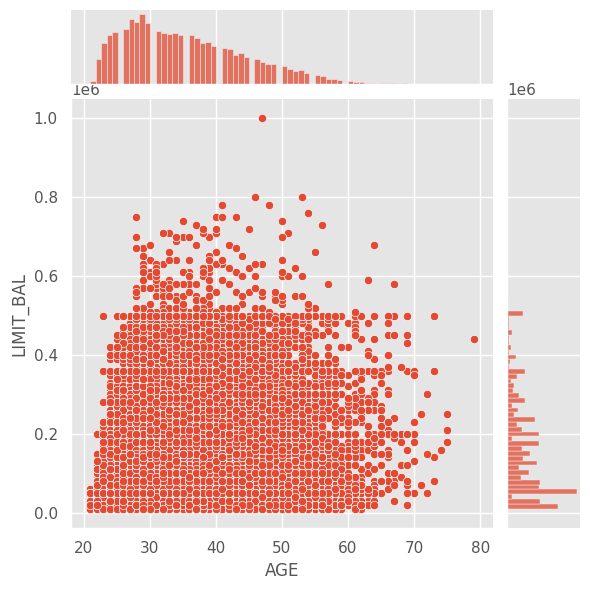

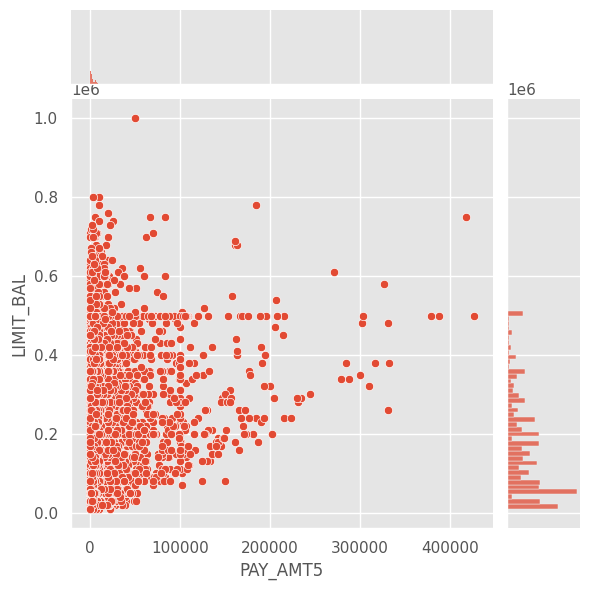

In [11]:
df_ALB = pd.DataFrame(df, columns=['LIMIT_BAL','AGE'])
sns.jointplot(x='AGE', y='LIMIT_BAL', data=df_ALB)
df_LBP = pd.DataFrame(df, columns=['PAY_AMT5', 'LIMIT_BAL'])
sns.jointplot(x='PAY_AMT5', y='LIMIT_BAL', data=df_LBP)

In [12]:
default_rate = df["default payment next month"].mean()
print(f"Default rate = {default_rate:.2%}")
defaulters = df[df["default payment next month"] == 1]
defaulters.mean()
avg_pay_2 = df[df["default payment next month"] == 1]["PAY_2"].mean()
print(f"Average PAY_2 for defaulters = {avg_pay_2:.2f} (×100 = {avg_pay_2*100:.0f}%)")
duly_paid = ((df["default payment next month"] == 1) & (df["PAY_0"] == -1)).sum()
portion = duly_paid / len(df)
print(f"Portion = {portion:.2%}")

Default rate = 22.12%
Average PAY_2 for defaulters = 0.46 (×100 = 46%)
Portion = 3.18%


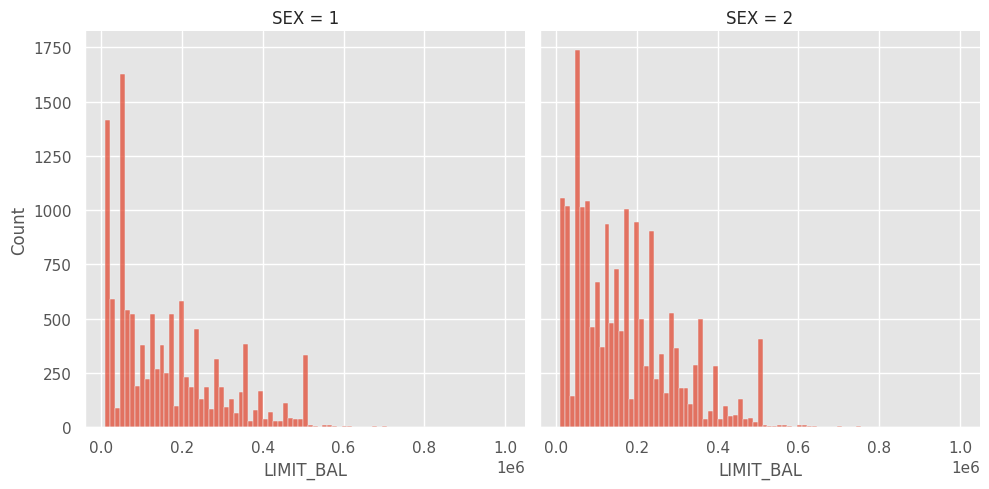

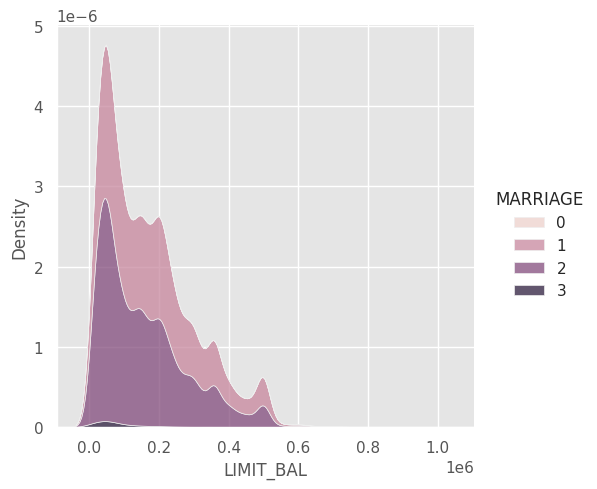

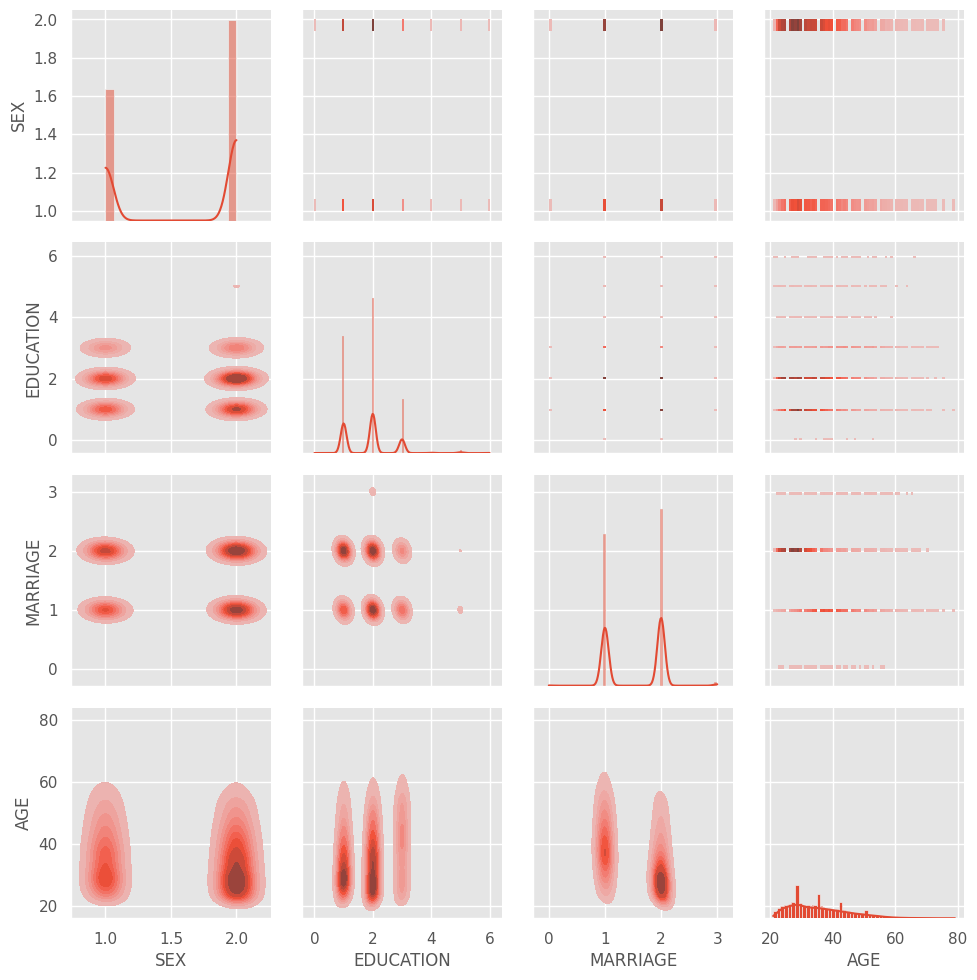

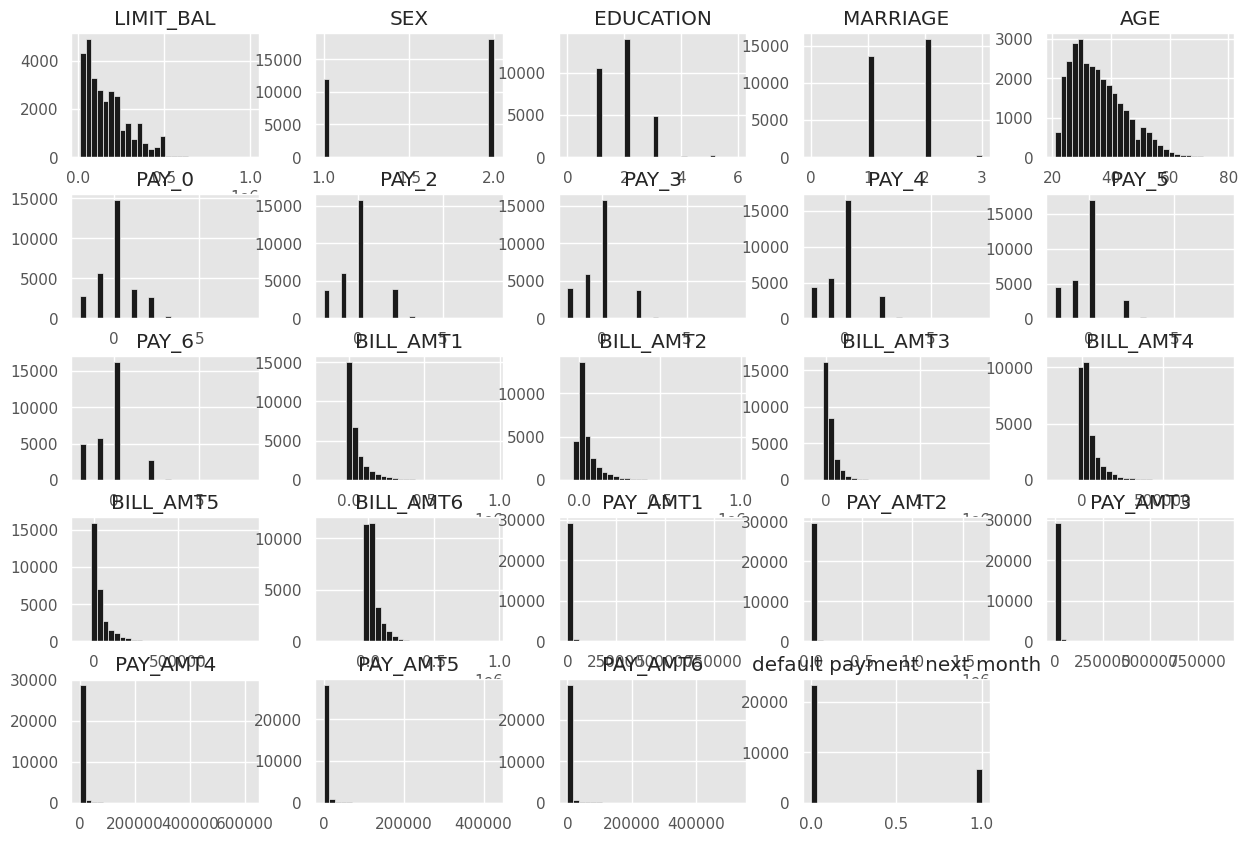

<Axes: xlabel='EDUCATION', ylabel='LIMIT_BAL'>

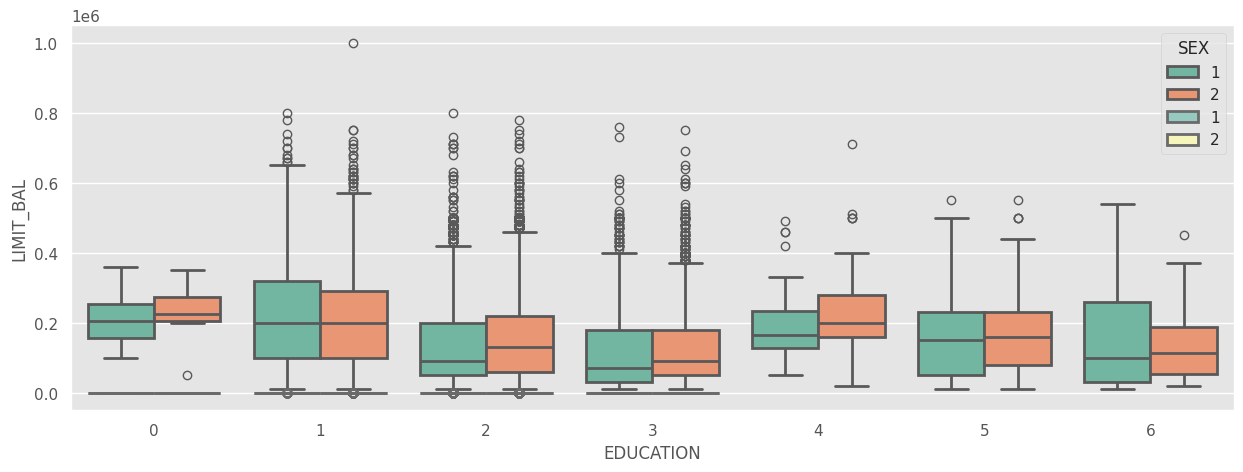

In [13]:
sns.displot(df, x="LIMIT_BAL", col="SEX", multiple="dodge")
sns.displot(df, x="LIMIT_BAL", hue="MARRIAGE", kind="kde", multiple="stack")
g = sns.PairGrid(df[['SEX', 'EDUCATION', 'MARRIAGE', 'AGE']])
g.map_upper(sns.histplot)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot, kde=True)
df["AGE"].hist(bins=50)
df.hist(color="k", bins=30, figsize=(15, 10))
plt.show()
sns.boxplot(x="EDUCATION", y="LIMIT_BAL", hue="SEX", data=df,
            linewidth=2.0, dodge=True, palette="Set2")
sns.boxplot(x="MARRIAGE", y="AGE", hue="SEX", data=df,
            linewidth=2.0, dodge=True, palette="Set3")

In [14]:
top_15 = df.sort_values(by="PAY_AMT1", ascending=False).head(15)
print("Top 15 clients (ID and PAY_AMT1, AGE):")
print(top_15[["PAY_AMT1", "AGE"]])
print("\nAverage PAY_AMT1:", top_15["PAY_AMT1"].mean())
print("Average AGE:", top_15["AGE"].mean())

Top 15 clients (ID and PAY_AMT1, AGE):
       PAY_AMT1  AGE
ID                  
28717    873552   42
12331    505000   37
28004    493358   30
29821    423903   37
8501     405016   28
2688     368199   44
29964    323014   31
25432    304815   28
5688     302000   39
29868    300039   29
6774     300000   32
3221     298887   36
17768    276698   53
17661    273844   42
8880     272817   26

Average PAY_AMT1: 381409.4666666667
Average AGE: 35.6


EDUCATION  MARRIAGE
0          1              4
           2             10
1          0              4
           1           3722
           2           6809
           3             50
2          0              6
           1           6842
           2           7020
           3            162
3          0             44
           1           2861
           2           1909
           3            103
4          1             52
           2             68
           3              3
5          1            150
           2            127
           3              3
6          1             28
           2             21
           3              2
dtype: int64
EDUCATION  MARRIAGE
0          1          39.250
           2          38.700
1          0          36.500
           1          40.484
           2          30.756
           3          41.980
2          0          36.167
           1          38.499
           2          30.899
           3          40.802
3          0 

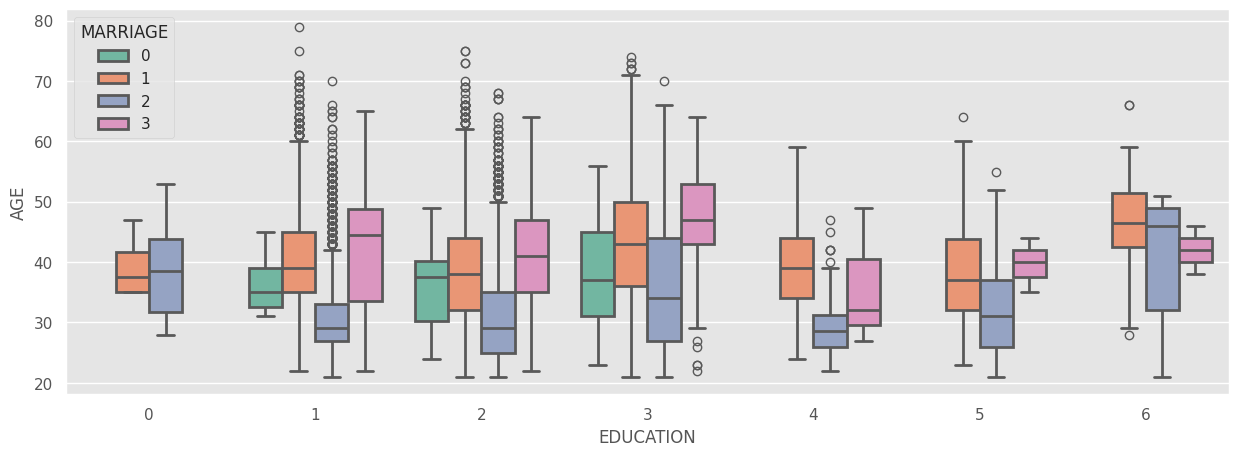

In [15]:
sns.boxplot(x="EDUCATION", y="AGE", hue="MARRIAGE",
            data=df, linewidth=2.0, dodge=True, palette="Set2")
counts = df.groupby(['EDUCATION', 'MARRIAGE']).size()
print(counts)
means = df.groupby(['EDUCATION', 'MARRIAGE'])['AGE'].mean()
print(means)

Libraries that were in use
pandas
matplotlib
seaborn
numpy
scikit-learn
openpyxl